In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd

with open("/content/drive/MyDrive/masterthesis/llama-4-maverick-17b-128e-instruct/zero_shot/Claim_only_output.json", "r", encoding="utf-8") as f:
    claim_only = json.load(f)
with open("/content/drive/MyDrive/masterthesis/llama-4-maverick-17b-128e-instruct/zero_shot/Claim_Premise_output.json", "r", encoding="utf-8") as f:
    claim_premise = json.load(f)
with open("/content/drive/MyDrive/masterthesis/llama-4-maverick-17b-128e-instruct/zero_shot/Claim_Premise_Argumentation_output.json", "r", encoding="utf-8") as f:
    claim_prem_arg = json.load(f)

with open("/content/drive/MyDrive/masterthesis/llama-4-maverick-17b-128e-instruct/baseline_output.json", "r", encoding="utf-8") as f:
    baseline = json.load(f)

In [ ]:
PERSONAS = [
    "Rawlsian philosopher",
    "Libertarian economist",
    "Utilitarian ethicist",
    "Conservative political theorist"
]

def json_to_df(data, prompt_type):
    df = pd.DataFrame(data)
    df['prompt_type'] = prompt_type
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())
    df['argument'] = df['response'].apply(lambda x: x.split("Argument:")[1].strip())
    return df

df_baseline = json_to_df(baseline, 'baseline')
df_claim_only = json_to_df(claim_only, 'claim_only')
df_claim_prem = json_to_df(claim_premise, 'claim_premise')
df_claim_prem_arg = json_to_df(claim_prem_arg, 'claim_prem_arg')

df_zero_shot = pd.concat([df_claim_only, df_claim_prem, df_claim_prem_arg], ignore_index=True)

In [ ]:
df_zero_shot.shape

(360, 8)

In [ ]:
from IPython.display import display, Markdown

display(Markdown(df_zero_shot.head().to_markdown()))

|    |   index | persona                         | claim                                                                                  | model                                         | response                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | prompt_type   | stance   | argument                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|---:|--------:|:--------------------------------|:---------------------------------------------------------------------------------------|:----------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:---------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  0 |       1 | Rawlsian philosopher            | This House would make all museums free of charge.                                      | meta-llama/llama-4-maverick-17b-128e-instruct | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | claim_only    | For      | As a Rawlsian philosopher, I support making all museums free of charge because it promotes the principle of equal opportunity and benefits the least advantaged members of society. By providing free access to cultural and educational resources, we can help bridge the gap between the privileged and the underprivileged. This aligns with the difference principle, which prioritizes policies that maximize the benefits to the most disadvantaged. Ensuring equal access to museums fosters a more just and equitable society.                                                                                                                       |
|    |         |                                 |                                                                                        |                                               | Argument: As a Rawlsian philosopher, I support making all museums free of charge because it promotes the principle of equal opportunity and benefits the least advantaged members of society. By providing free access to cultural and educational resources, we can help bridge the gap between the privileged and the underprivileged. This aligns with the difference principle, which prioritizes policies that maximize the benefits to the most disadvantaged. Ensuring equal access to museums fosters a more just and equitable society.                                                                                                                       |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
|  1 |       1 | Libertarian economist           | This House would make all museums free of charge.                                      | meta-llama/llama-4-maverick-17b-128e-instruct | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        | claim_only    | Against  | As a Libertarian economist, I believe that making all museums free of charge would be a misguided policy, as it would require significant government expenditure and potentially distort market incentives. Museums should be free to set their own prices based on consumer demand, allowing them to operate more efficiently. By charging admission fees, museums can also ensure that those who benefit from their services are the ones who pay for them, rather than relying on coercive taxation.                                                                                                                                                      |
|    |         |                                 |                                                                                        |                                               | Argument: As a Libertarian economist, I believe that making all museums free of charge would be a misguided policy, as it would require significant government expenditure and potentially distort market incentives. Museums should be free to set their own prices based on consumer demand, allowing them to operate more efficiently. By charging admission fees, museums can also ensure that those who benefit from their services are the ones who pay for them, rather than relying on coercive taxation.                                                                                                                                                      |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
|  2 |       1 | Utilitarian ethicist            | This House would make all museums free of charge.                                      | meta-llama/llama-4-maverick-17b-128e-instruct | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | claim_only    | For      | As a Utilitarian ethicist, I support making all museums free of charge because it would maximize overall happiness by providing universal access to cultural and educational resources. By removing the financial barrier, we can promote a greater good and foster a more informed and enlightened society. This decision would likely lead to a significant increase in museum attendance, thereby spreading the benefits of art, history, and science to a broader audience. Ultimately, this policy would contribute to the greatest happiness for the greatest number.                                                                                  |
|    |         |                                 |                                                                                        |                                               | Argument: As a Utilitarian ethicist, I support making all museums free of charge because it would maximize overall happiness by providing universal access to cultural and educational resources. By removing the financial barrier, we can promote a greater good and foster a more informed and enlightened society. This decision would likely lead to a significant increase in museum attendance, thereby spreading the benefits of art, history, and science to a broader audience. Ultimately, this policy would contribute to the greatest happiness for the greatest number.                                                                                  |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
|  3 |       1 | Conservative political theorist | This House would make all museums free of charge.                                      | meta-llama/llama-4-maverick-17b-128e-instruct | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        | claim_only    | Against  | As a conservative, I believe that making all museums free of charge would undermine the principle of personal responsibility and the value of investing in one's own cultural enrichment. Museums often rely on entrance fees to maintain their operations and provide high-quality exhibits, and eliminating these fees could compromise their ability to deliver. Furthermore, subsidizing museum visits for everyone, including those who may not appreciate or benefit from them, is not a prudent use of taxpayer money. It is more sensible to allow individuals to make their own choices about how to spend their leisure time and money.            |
|    |         |                                 |                                                                                        |                                               | Argument: As a conservative, I believe that making all museums free of charge would undermine the principle of personal responsibility and the value of investing in one's own cultural enrichment. Museums often rely on entrance fees to maintain their operations and provide high-quality exhibits, and eliminating these fees could compromise their ability to deliver. Furthermore, subsidizing museum visits for everyone, including those who may not appreciate or benefit from them, is not a prudent use of taxpayer money. It is more sensible to allow individuals to make their own choices about how to spend their leisure time and money.            |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
|  4 |       2 | Rawlsian philosopher            | This House would permit the use of performance enhancing drugs in professional sports. | meta-llama/llama-4-maverick-17b-128e-instruct | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        | claim_only    | Against  | As a Rawlsian philosopher, I prioritize the principles of justice and fairness. Permitting performance-enhancing drugs in professional sports would undermine the fair equality of opportunity and the integrity of competition, as it would create an uneven playing field. In the original position, rational individuals behind the veil of ignorance would likely reject such a policy, as it would compromise the basic liberties and the dignity of athletes. This decision aligns with the maximin principle, which prioritizes the well-being of the least advantaged, in this case, the athletes who choose not to use performance-enhancing drugs. |
|    |         |                                 |                                                                                        |                                               | Argument: As a Rawlsian philosopher, I prioritize the principles of justice and fairness. Permitting performance-enhancing drugs in professional sports would undermine the fair equality of opportunity and the integrity of competition, as it would create an uneven playing field. In the original position, rational individuals behind the veil of ignorance would likely reject such a policy, as it would compromise the basic liberties and the dignity of athletes. This decision aligns with the maximin principle, which prioritizes the well-being of the least advantaged, in this case, the athletes who choose not to use performance-enhancing drugs. |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |

In [ ]:
def check_stance_flip(row, df_base):

    base_row = df_base[df_base['index'] == row['index']]

    if base_row.empty:
        return 0

    base_stance = base_row.iloc[0]['stance']


    current_stance = str(row['stance']).strip().lower()
    baseline_stance = str(base_stance).strip().lower()


    if current_stance == baseline_stance or current_stance in baseline_stance or baseline_stance in current_stance:
        return 1
    else:
        return 0

df_zero_shot['stance_consistent'] = df_zero_shot.apply(lambda row: check_stance_flip(row, df_baseline), axis=1)

print("\n--- Stance Consistency Rate (vs Baseline) ---")
print(df_zero_shot.groupby('prompt_type')['stance_consistent'].mean())
print("---------------------------------------------\n")


--- Stance Consistency Rate (vs Baseline) ---
prompt_type
claim_only        0.616667
claim_prem_arg    0.575000
claim_premise     0.525000
Name: stance_consistent, dtype: float64
---------------------------------------------



1. Effectiveness of Persona:

$$Distance(A, B) = 1 - \frac{A \cdot B}{\|A\| \|B\|}$$

$Distance = 1 - CosineSimilarity(Vec_{Baseline}, Vec_{Persona})$

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
df_baseline['embedding'] = df_baseline['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))
df_zero_shot['embedding'] = df_zero_shot['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))

# Cosine Distance vs baseline
from sentence_transformers import util
df_zero_shot['cosine_distance'] = df_zero_shot.apply(
    lambda row: 1 - util.cos_sim(row['embedding'], df_baseline.loc[df_baseline['index']==row['index'], 'embedding'].values[0]).item(),
    axis=1
)

summary = df_zero_shot.groupby('prompt_type')['cosine_distance'].agg(['mean','std','count']).reset_index()
print(summary)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

      prompt_type      mean       std  count
0      claim_only  0.255622  0.082889    120
1  claim_prem_arg  0.288091  0.099915    120
2   claim_premise  0.277641  0.089956    120


In [ ]:
from scipy.stats import ttest_rel
import numpy as np

df_sorted = df_zero_shot.sort_values('index')


co = df_sorted[df_sorted['prompt_type']=='claim_only']['cosine_distance'].tolist()
cp = df_sorted[df_sorted['prompt_type']=='claim_premise']['cosine_distance'].tolist()
cpa = df_sorted[df_sorted['prompt_type']=='claim_prem_arg']['cosine_distance'].tolist()

if len(co) == len(cp) == len(cpa):

    print("claim_only vs claim_premise:", ttest_rel(co, cp))
    print("claim_only vs claim_prem_arg:", ttest_rel(co, cpa))
    print("claim_premise vs claim_prem_arg:", ttest_rel(cp, cpa))
else:
    print("error")

from scipy.stats import wilcoxon
print("\nWilcoxon Test (Non-parametric alternative):")
print("co vs cp:", wilcoxon(co, cp))

claim_only vs claim_premise: TtestResult(statistic=np.float64(-3.063378737196676), pvalue=np.float64(0.002707181976499082), df=np.int64(119))
claim_only vs claim_prem_arg: TtestResult(statistic=np.float64(-3.4469404230512666), pvalue=np.float64(0.0007843551868334724), df=np.int64(119))
claim_premise vs claim_prem_arg: TtestResult(statistic=np.float64(-1.0780442332899607), pvalue=np.float64(0.2831944457614148), df=np.int64(119))

Wilcoxon Test (Non-parametric alternative):
co vs cp: WilcoxonResult(statistic=np.float64(2430.0), pvalue=np.float64(0.0016742995359048881))


/tmp/ipython-input-2241555319.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(x='prompt_type', y='cosine_distance', data=df_zero_shot,


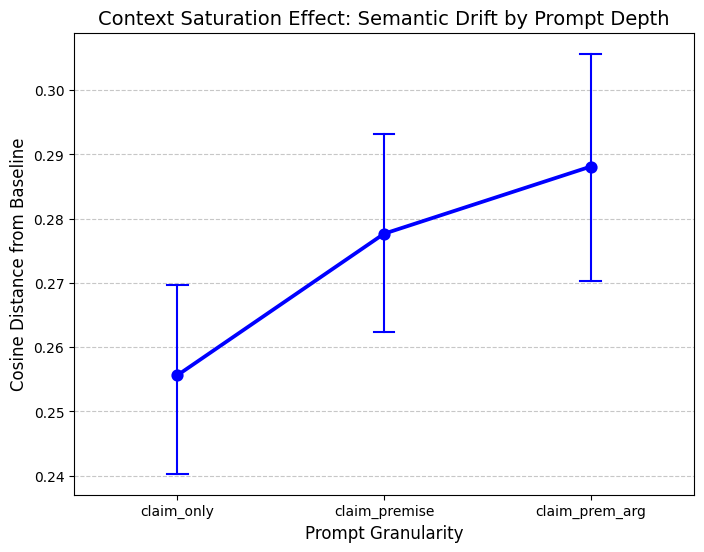

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.pointplot(x='prompt_type', y='cosine_distance', data=df_zero_shot,
              order=['claim_only', 'claim_premise', 'claim_prem_arg'],
              capsize=.1, errwidth=1.5, color='b')

plt.title('Context Saturation Effect: Semantic Drift by Prompt Depth', fontsize=14)
plt.ylabel('Cosine Distance from Baseline', fontsize=12)
plt.xlabel('Prompt Granularity', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

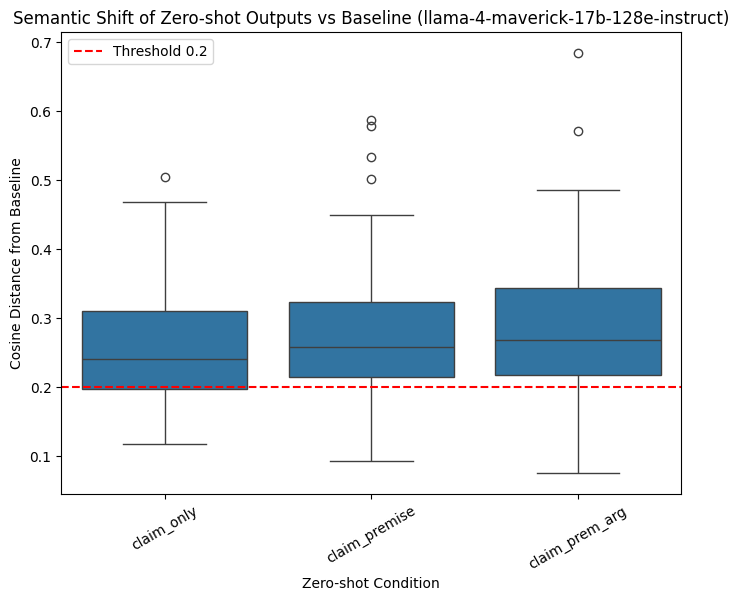

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='prompt_type', y='cosine_distance', data=df_zero_shot)
plt.axhline(0.2, color='red', linestyle='--', label='Threshold 0.2')
plt.ylabel("Cosine Distance from Baseline")
plt.xlabel("Zero-shot Condition")
plt.title("Semantic Shift of Zero-shot Outputs vs Baseline (llama-4-maverick-17b-128e-instruct)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

2. Lexical Distinctiveness

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


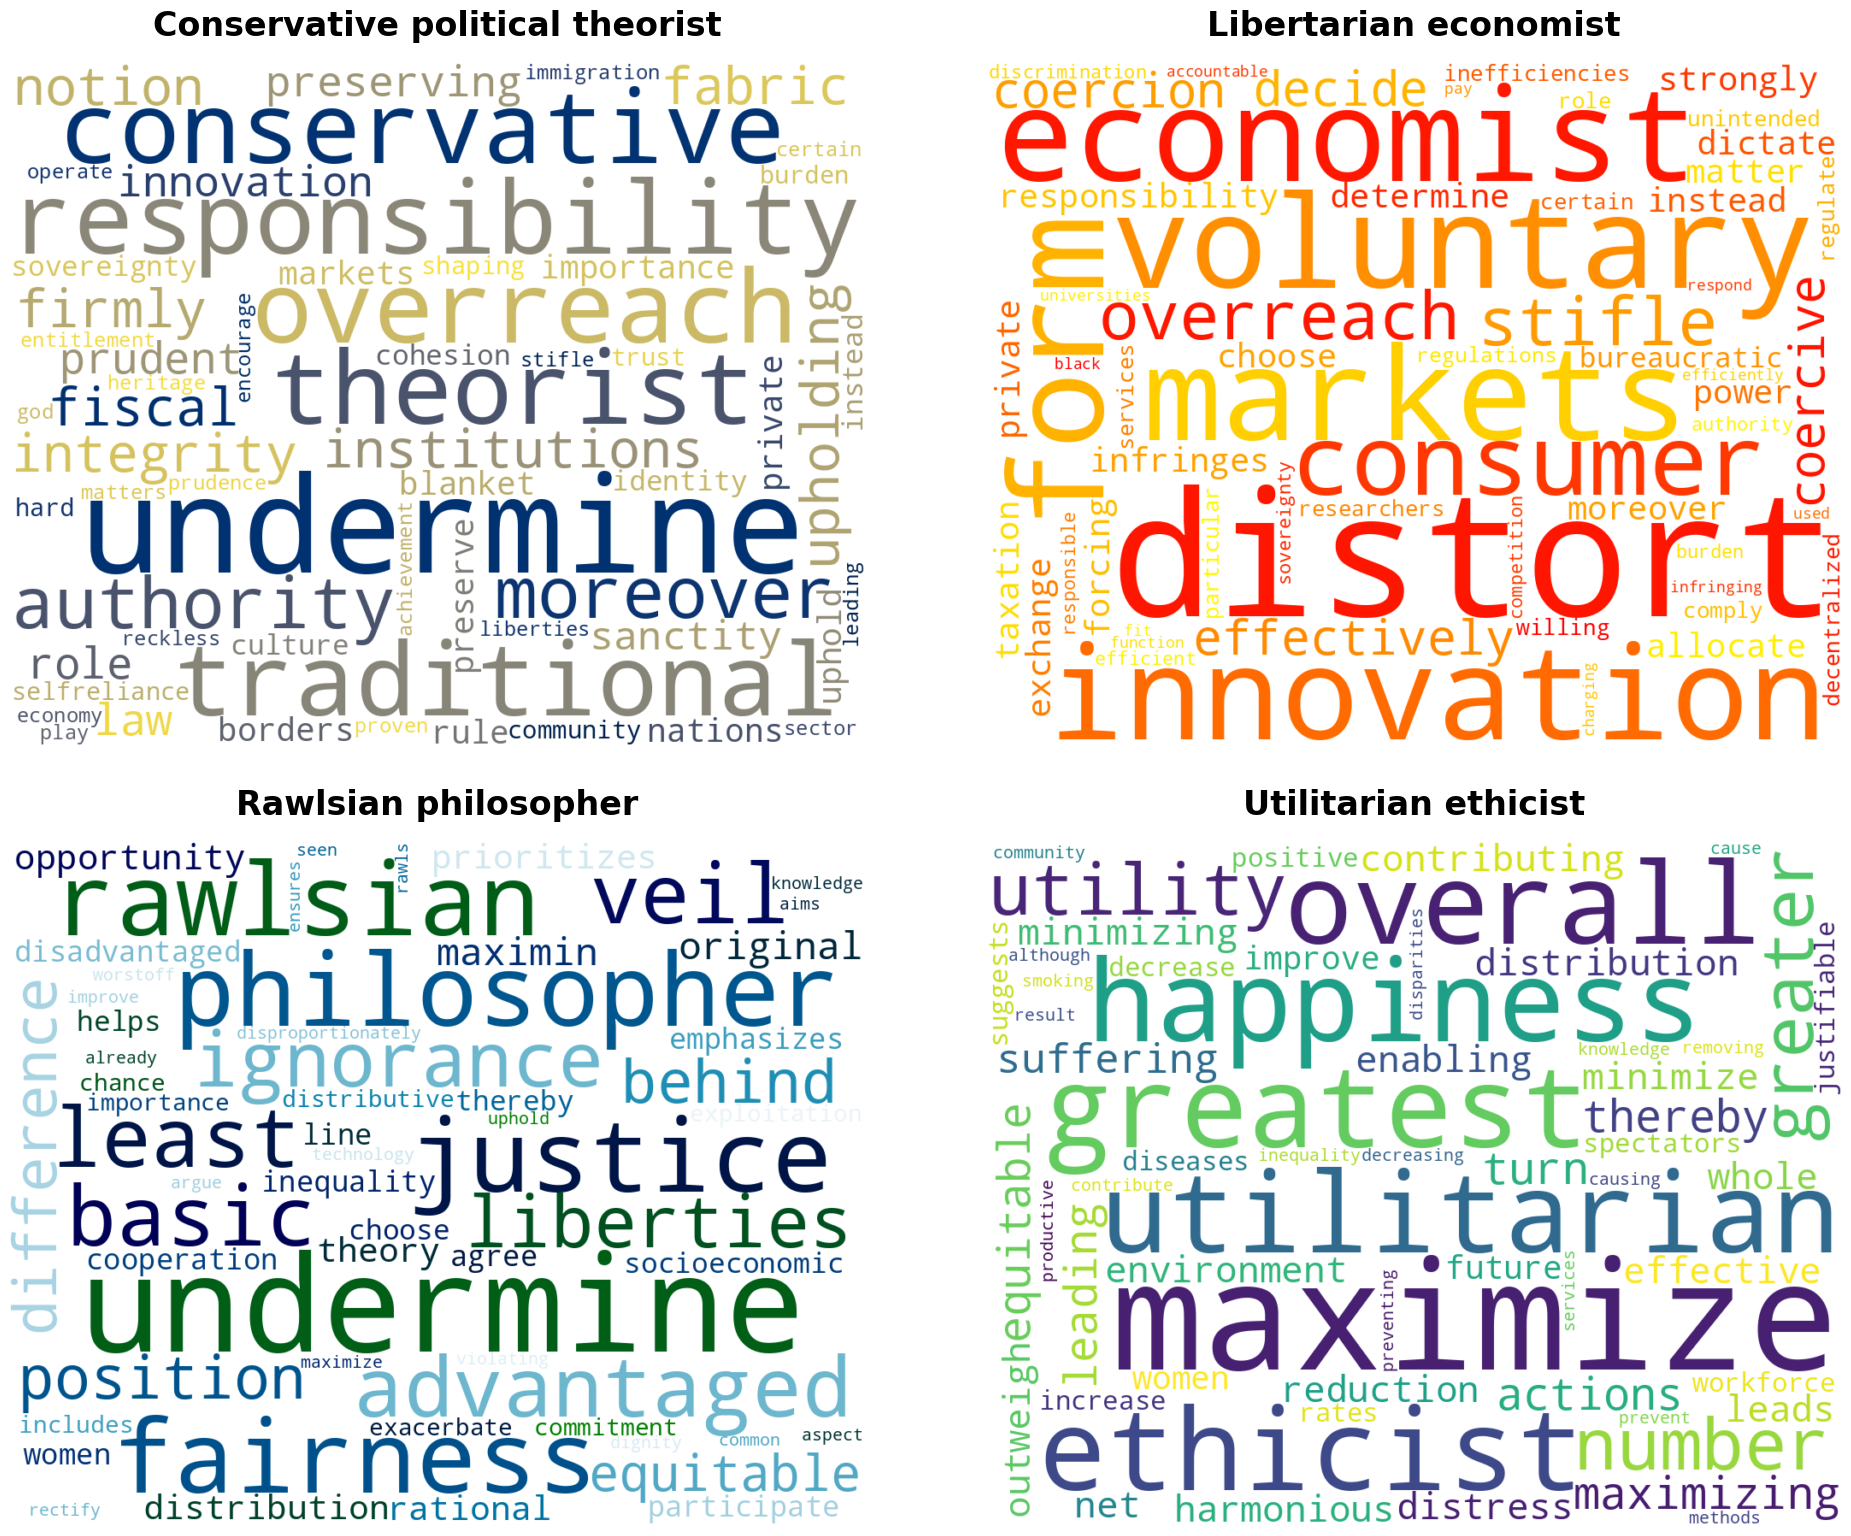

In [ ]:
import pandas as pd
import re
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
domain_stops = {
    'argument', 'premise', 'claim', 'would', 'could', 'should',
    'support', 'oppose', 'stance', 'response', 'therefore',
    'however', 'perspective', 'view', 'opinion', 'believe',
    'society', 'individual', 'people', 'must', 'us',
    'example', 'instance', 'case'
}
stop_words.update(domain_stops)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

def extract_keywords(df, k=50):
    target_col = 'argument' if 'argument' in df.columns else 'response'

    grouped = df.groupby('persona')[target_col].apply(lambda x: " ".join(str(v) for v in x)).reset_index()
    grouped['clean_text'] = grouped[target_col].apply(preprocess_text)

    vectorizer = TfidfVectorizer(max_df=0.8, max_features=2000)
    try:
        tfidf_matrix = vectorizer.fit_transform(grouped['clean_text'])
    except ValueError:
        return {}

    feature_names = vectorizer.get_feature_names_out()
    keywords_map = {}

    for i, row in grouped.iterrows():
        persona_name = row['persona']
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[::-1][:k]
        keywords_map[persona_name] = [feature_names[idx] for idx in top_indices]

    return keywords_map

def generate_wordcloud_grid(keywords_map, output_filename="zero_shot_lexical_grid.png"):
    personas = list(keywords_map.keys())
    n_personas = len(personas)
    cols = 2
    rows = math.ceil(n_personas / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))
    axes = axes.flatten()

    colormaps = {
        'Libertarian economist': 'autumn',
        'Conservative political theorist': 'cividis',
        'Rawlsian philosopher': 'ocean',
        'Utilitarian ethicist': 'viridis'
    }
    default_cmap = 'coolwarm'

    for i, persona_name in enumerate(personas):
        ax = axes[i]
        word_list = keywords_map[persona_name]
        text_data = " ".join(word_list)

        wc = WordCloud(
            width=1000,
            height=800,
            background_color='white',
            max_words=60,
            colormap=colormaps.get(persona_name, default_cmap),
            collocations=False,
            random_state=42
        )
        wc.generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(persona_name, fontsize=24, fontweight='bold', pad=20)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=3.0)
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

df_filtered = df_zero_shot[df_zero_shot['persona'] != 'Baseline'].copy()
top_keywords_zeroshot = extract_keywords(df_filtered, k=60)

if top_keywords_zeroshot:
    generate_wordcloud_grid(top_keywords_zeroshot)
else:
    print("Error: Failed to extract keywords.")

Distinct Lexical Clusters

In [ ]:
def calculate_overlap_metrics(keywords_map, top_k=50):
    import itertools

    personas = list(keywords_map.keys())
    persona_sets = {p: set(keywords_map[p][:top_k]) for p in personas}


    for p1, p2 in itertools.combinations(personas, 2):
        set1 = persona_sets[p1]
        set2 = persona_sets[p2]

        intersection = set1.intersection(set2)
        union = set1.union(set2)

        # Jaccard Score
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0

        print(f"{p1} vs {p2}:")
        print(f"  - Jaccard Score: {jaccard:.4f}")
        print(f"  - Overlapping Words: {list(intersection) if intersection else 'None'}")
        print("-" * 30)


if 'top_keywords_zeroshot' in locals() and top_keywords_zeroshot:
    print("Detected 'top_keywords_zeroshot'. Running analysis...")
    calculate_overlap_metrics(top_keywords_zeroshot, top_k=50)


else:
    print("Error: cannot find the keywords")

Detected 'top_keywords_zeroshot'. Running analysis...
Conservative political theorist vs Libertarian economist:
  - Jaccard Score: 0.1236
  - Overlapping Words: ['authority', 'moreover', 'responsibility', 'innovation', 'sovereignty', 'overreach', 'burden', 'private', 'instead', 'role', 'markets']
------------------------------
Conservative political theorist vs Rawlsian philosopher:
  - Jaccard Score: 0.0204
  - Overlapping Words: ['undermine', 'importance']
------------------------------
Conservative political theorist vs Utilitarian ethicist:
  - Jaccard Score: 0.0101
  - Overlapping Words: ['leading']
------------------------------
Libertarian economist vs Rawlsian philosopher:
  - Jaccard Score: 0.0101
  - Overlapping Words: ['choose']
------------------------------
Libertarian economist vs Utilitarian ethicist:
  - Jaccard Score: 0.0101
  - Overlapping Words: ['services']
------------------------------
Rawlsian philosopher vs Utilitarian ethicist:
  - Jaccard Score: 0.0638
  - Ove

3. Stance Consistency

In [ ]:
df_zero_shot['stance'] = df_zero_shot['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_baseline['stance'] = df_baseline['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_zero_shot['flip'] = df_zero_shot.apply(
    lambda row: row['stance'] != df_baseline.loc[df_baseline['index'] == row['index'], 'stance'].values[0],
    axis=1
)

flip_rate = df_zero_shot.groupby(['persona', 'prompt_type'])['flip'].mean().reset_index()
flip_rate['flip_percentage'] = flip_rate['flip'] * 100
print(flip_rate)

                            persona     prompt_type      flip  flip_percentage
0   Conservative political theorist      claim_only  0.566667        56.666667
1   Conservative political theorist  claim_prem_arg  0.633333        63.333333
2   Conservative political theorist   claim_premise  0.600000        60.000000
3             Libertarian economist      claim_only  0.566667        56.666667
4             Libertarian economist  claim_prem_arg  0.600000        60.000000
5             Libertarian economist   claim_premise  0.700000        70.000000
6              Rawlsian philosopher      claim_only  0.166667        16.666667
7              Rawlsian philosopher  claim_prem_arg  0.200000        20.000000
8              Rawlsian philosopher   claim_premise  0.166667        16.666667
9              Utilitarian ethicist      claim_only  0.233333        23.333333
10             Utilitarian ethicist  claim_prem_arg  0.266667        26.666667
11             Utilitarian ethicist   claim_premise 

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

conservative_baseline_prob = 0.01

results = []

for persona in df_zero_shot['persona'].unique():
    for prompt in df_zero_shot['prompt_type'].unique():

        subset = df_zero_shot[(df_zero_shot['persona']==persona) &
                              (df_zero_shot['prompt_type']==prompt)]

        persona_flips_count = subset['flip'].sum()
        persona_nobs = len(subset)


        if persona_flips_count == 0:
            p_value = 1.0
        else:
            # One-Sample Z-test
            # H0: p <= 0.01  vs  H1: p > 0.01
            try:
                stat, p_value = proportions_ztest(
                    count=persona_flips_count,
                    nobs=persona_nobs,
                    value=conservative_baseline_prob,
                    alternative='larger'
                )
            except Exception as e:
                p_value = 1.0

        results.append({
            "model": "llama-4-maverick-17b-128e-instruct",
            "persona": persona,
            "prompt_type": prompt,
            "persona_flip_rate": f"{persona_flips_count/persona_nobs:.2%}",
            "noise_baseline": "0.00% (Test vs 1%)",
            "p_value": round(p_value, 4),
            "is_significant": "Yes" if p_value < 0.05 else "No"
        })

df_final_stats = pd.DataFrame(results)
print(df_final_stats)

                                 model                          persona  \
0   llama-4-maverick-17b-128e-instruct             Rawlsian philosopher   
1   llama-4-maverick-17b-128e-instruct             Rawlsian philosopher   
2   llama-4-maverick-17b-128e-instruct             Rawlsian philosopher   
3   llama-4-maverick-17b-128e-instruct            Libertarian economist   
4   llama-4-maverick-17b-128e-instruct            Libertarian economist   
5   llama-4-maverick-17b-128e-instruct            Libertarian economist   
6   llama-4-maverick-17b-128e-instruct             Utilitarian ethicist   
7   llama-4-maverick-17b-128e-instruct             Utilitarian ethicist   
8   llama-4-maverick-17b-128e-instruct             Utilitarian ethicist   
9   llama-4-maverick-17b-128e-instruct  Conservative political theorist   
10  llama-4-maverick-17b-128e-instruct  Conservative political theorist   
11  llama-4-maverick-17b-128e-instruct  Conservative political theorist   

       prompt_type perso

Argument Dilution Effect：Utilitarian

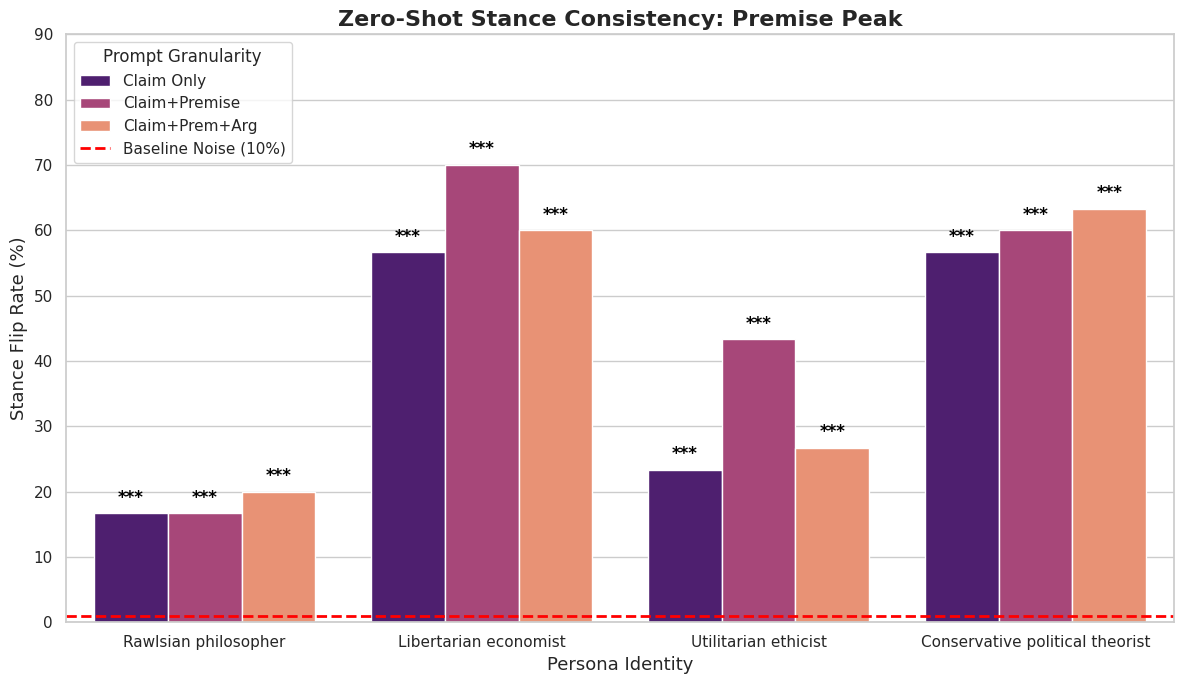

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = df_final_stats.copy()


df_plot['flip_val'] = df_plot['persona_flip_rate'].str.rstrip('%').astype(float)

df_plot['prompt_label'] = df_plot['prompt_type'].replace({
    'claim_only': 'Claim Only',
    'claim_premise': 'Claim+Premise',
    'claim_prem_arg': 'Claim+Prem+Arg'
})


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")


ax = sns.barplot(
    x='persona',
    y='flip_val',
    hue='prompt_label',
    data=df_plot,
    palette='magma'
)


plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline Noise (10%)')


for container in ax.containers:
    for bar in container:

        height = bar.get_height()

        if height > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                '***',
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold'
            )
        else:
             ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                'n.s.',
                ha='center', va='bottom', fontsize=9, color='gray'
            )

plt.title('Zero-Shot Stance Consistency: Premise Peak', fontsize=16, fontweight='bold')
plt.ylabel('Stance Flip Rate (%)', fontsize=13)
plt.xlabel('Persona Identity', fontsize=13)
plt.ylim(0, 90)
plt.legend(title='Prompt Granularity', loc='upper left')

plt.tight_layout()
plt.show()

4. Cross-Prompt Consistency Analysis (Prompt Sensitivity Test, Robustness)

In [ ]:
def extract_stance(df):
    df = df.copy()
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:", "").strip())
    return df[['index', 'persona', 'stance']]

df_claim_only_s = extract_stance(df_claim_only).rename(columns={'stance':'stance_claim_only'})
df_claim_prem_s = extract_stance(df_claim_prem).rename(columns={'stance':'stance_claim_prem'})
df_claim_prem_arg_s = extract_stance(df_claim_prem_arg).rename(columns={'stance':'stance_claim_prem_arg'})

df_stance = df_claim_only_s.merge(df_claim_prem_s, on=['index','persona'])
df_stance = df_stance.merge(df_claim_prem_arg_s, on=['index','persona'])

In [ ]:
df_stance['all_equal'] = (df_stance['stance_claim_only'] == df_stance['stance_claim_prem']) & \
                         (df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg'])

df_stance['only_vs_prem'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem']
df_stance['only_vs_premarg'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg']
df_stance['prem_vs_premarg'] = df_stance['stance_claim_prem'] == df_stance['stance_claim_prem_arg']


In [ ]:
total = len(df_stance)
all_equal_ratio = df_stance['all_equal'].sum() / total
only_vs_prem_ratio = df_stance['only_vs_prem'].sum() / total
only_vs_premarg_ratio = df_stance['only_vs_premarg'].sum() / total
prem_vs_premarg_ratio = df_stance['prem_vs_premarg'].sum() / total

print(f"All three prompts equal: {all_equal_ratio:.2f}") # Rigidity
print(f"claim_only vs claim_prem: {only_vs_prem_ratio:.2f}") # Persuasiveness/Context Impact
print(f"claim_only vs claim_prem_arg: {only_vs_premarg_ratio:.2f}") # Marginal Utility of Argument
print(f"claim_prem vs claim_prem_arg: {prem_vs_premarg_ratio:.2f}")

All three prompts equal: 0.76
claim_only vs claim_prem: 0.84
claim_only vs claim_prem_arg: 0.81
claim_prem vs claim_prem_arg: 0.86


High Sensitivity to Argumentation

5. Topic

In [ ]:
import pandas as pd

# 10 topics, each with 3 arguments
topics = [
    "Culture", "Digital Freedoms", "Economy", "Education", "Environment",
    "Health", "Science", "Religion", "Philosophy", "Society"
]

# Assign each of the 30 unique arguments to a topic
topic_list = []
for t in topics:
    topic_list.extend([t]*3)  # each topic has 3 arguments

# Create a DataFrame mapping argument index to topic
df_topic = pd.DataFrame({
    'index': range(1, 31),  # argument indices 1 to 30
    'topic': topic_list
})

# Merge topic information into the stance DataFrame
df_stance_topic = df_stance.merge(df_topic, on='index', how='left')

# Calculate stance inconsistency per topic
# Use only 'all_equal' column in lambda to avoid the DeprecationWarning
topic_inconsistency = df_stance_topic.groupby('topic')['all_equal'].apply(
    lambda x: 1 - x.mean()
).sort_values(ascending=False)

# Print the inconsistency ratios
print("Topic inconsistency ratios:")
print(topic_inconsistency)

Topic inconsistency ratios:
topic
Philosophy          0.583333
Science             0.416667
Education           0.333333
Religion            0.333333
Society             0.250000
Environment         0.166667
Health              0.166667
Digital Freedoms    0.083333
Economy             0.083333
Culture             0.000000
Name: all_equal, dtype: float64


/tmp/ipython-input-245707316.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='viridis')


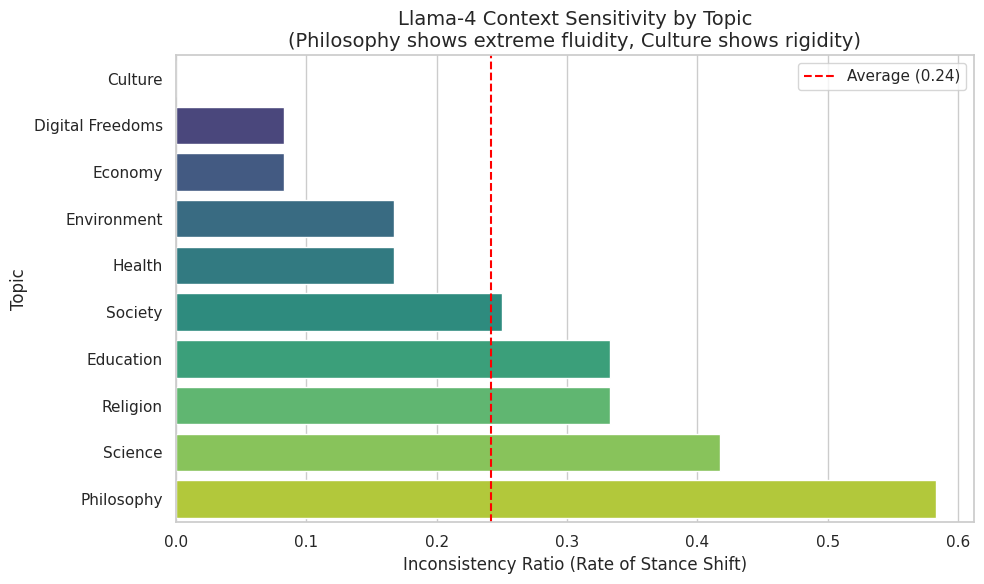

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


data = {
    'Philosophy': 0.583, 'Science': 0.417, 'Education': 0.333, 'Religion': 0.333,
    'Society': 0.250, 'Environment': 0.167, 'Health': 0.167,
    'Digital Freedoms': 0.083, 'Economy': 0.083, 'Culture': 0.000
}

df_plot = pd.DataFrame(list(data.items()), columns=['Topic', 'Inconsistency Ratio'])
df_plot = df_plot.sort_values('Inconsistency Ratio', ascending=True)

plt.figure(figsize=(10, 6))

sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='viridis')

plt.title('Llama-4 Context Sensitivity by Topic\n(Philosophy shows extreme fluidity, Culture shows rigidity)', fontsize=14)
plt.xlabel('Inconsistency Ratio (Rate of Stance Shift)', fontsize=12)
plt.ylabel('Topic', fontsize=12)

avg_ratio = df_plot['Inconsistency Ratio'].mean()
plt.axvline(x=avg_ratio, color='red', linestyle='--', label=f'Average ({avg_ratio:.2f})')
plt.legend()

plt.tight_layout()
plt.show()

Source of Variance: Topic-Driven or Persona-Driven

Inter-Persona Divergence Inter-Topic Divergence

/usr/local/lib/python3.12/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)



--- Variance Analysis Results ---
Avg Distance between Personas: 0.5317
Avg Distance between Topics:   0.6576
Conclusion: Topic-Driven


/tmp/ipython-input-3056465666.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='inter_persona_distance', y='topic', data=inter_persona_sorted, palette='magma')


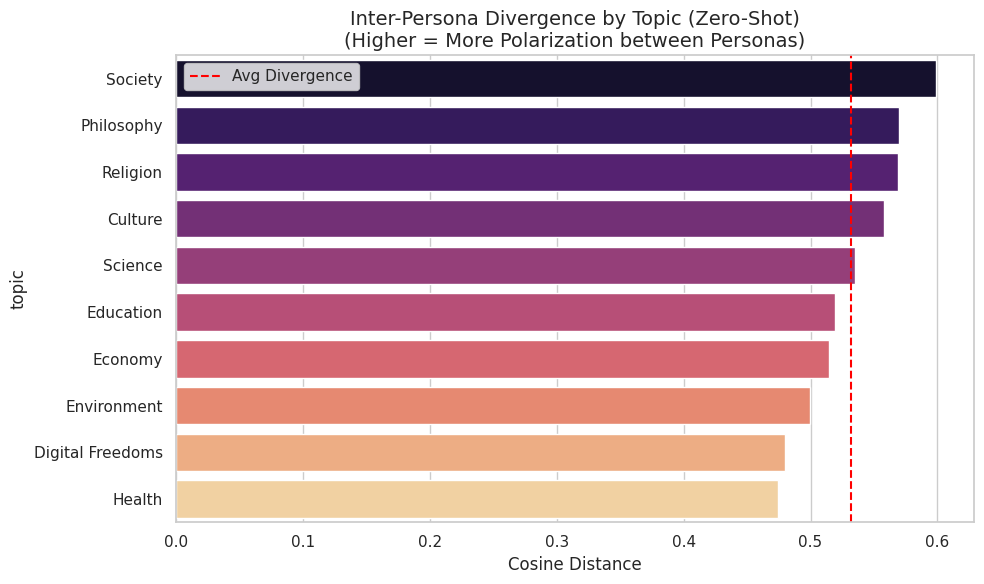

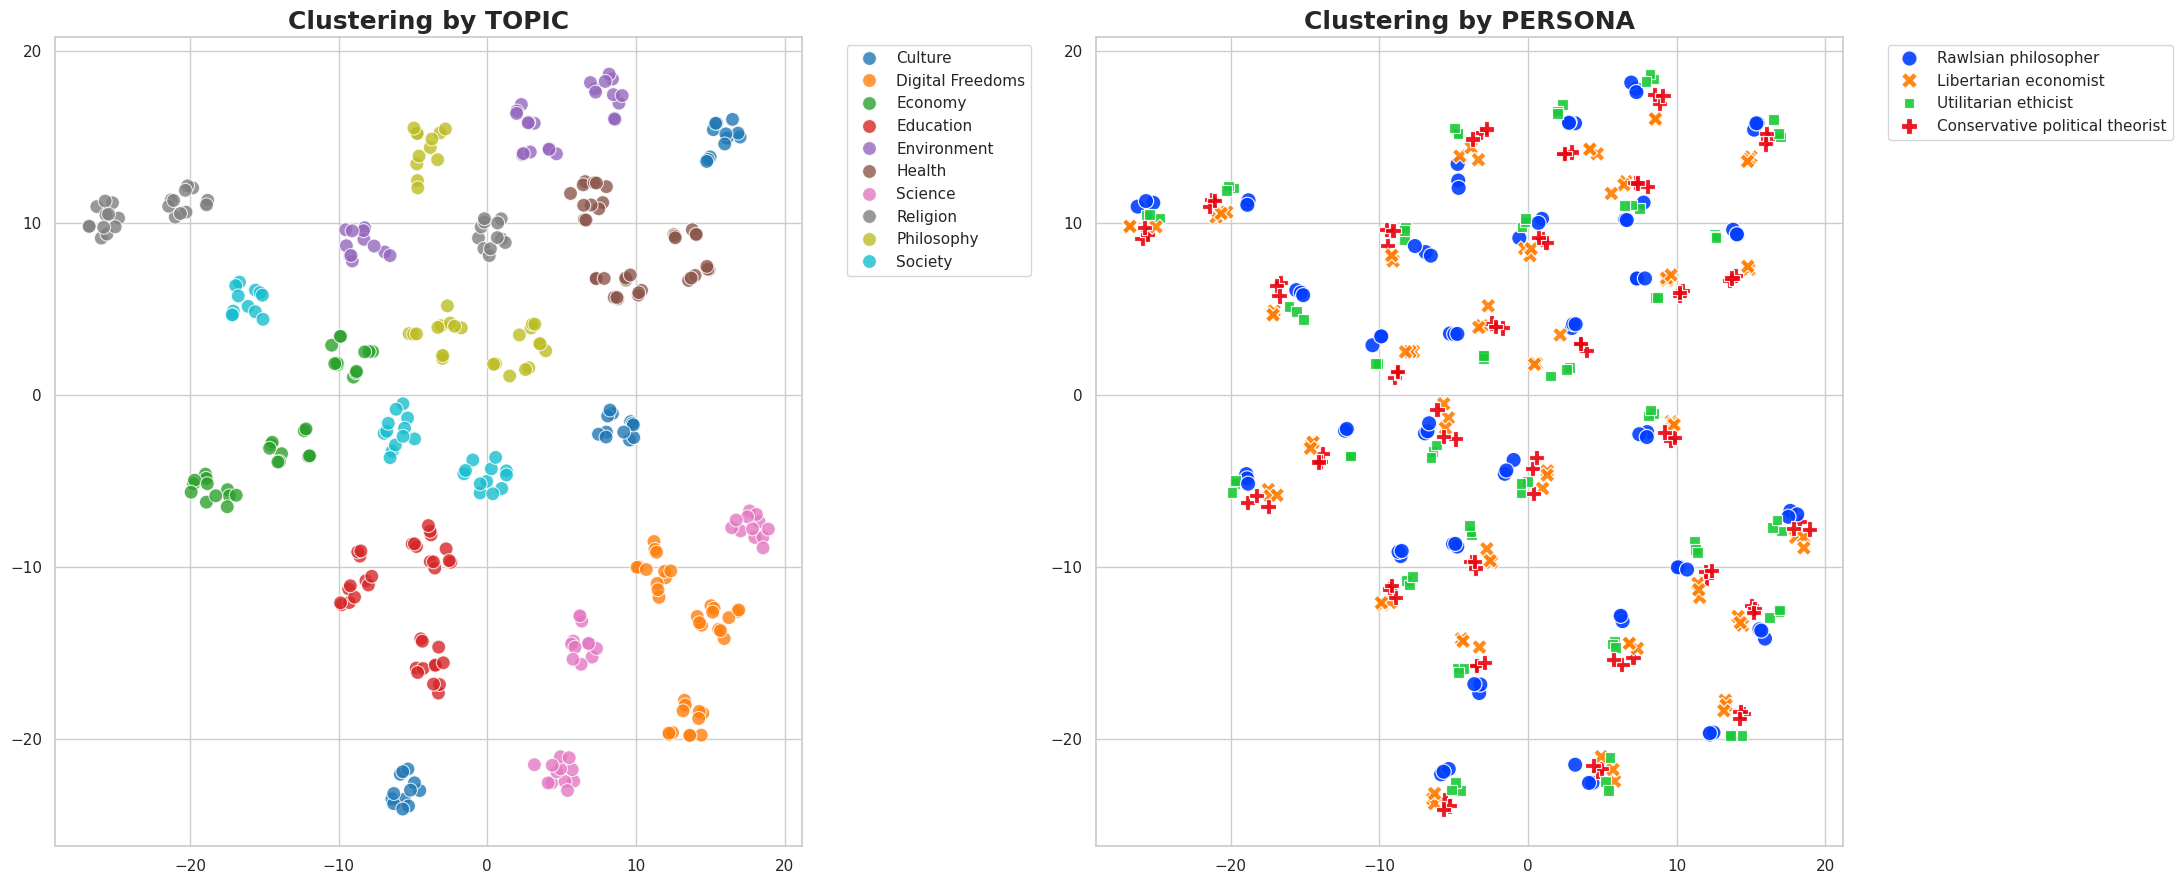

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
import torch

def ensure_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().detach().numpy()
    return x

df_zero_shot['embedding'] = df_zero_shot['embedding'].apply(ensure_numpy)


topics = ["Culture", "Digital Freedoms", "Economy", "Education", "Environment",
          "Health", "Science", "Religion", "Philosophy", "Society"]
topic_mapping = []
for t in topics:
    topic_mapping.extend([t]*3)

df_topic = pd.DataFrame({'index': range(1, 31), 'topic': topic_mapping})

if 'topic' not in df_zero_shot.columns:
    df_zero_shot = df_zero_shot.merge(df_topic, on='index', how='left')


def calculate_pairwise_divergence(embeddings):

    if len(embeddings) < 2: return 0

    sim_matrix = util.cos_sim(embeddings, embeddings)

    distances = []
    rows, cols = sim_matrix.shape
    for r in range(rows):
        for c in range(r + 1, cols):
            distances.append(1 - sim_matrix[r][c].item())

    return np.mean(distances)


# 指标 A: 同一个 Topic 下，不同 Persona 的距离
metric_persona_div = df_zero_shot.groupby('topic')['embedding'].apply(
    lambda x: calculate_pairwise_divergence(list(x))
).reset_index(name='inter_persona_distance')
metric_persona_div['type'] = 'Between Personas (Same Topic)'

# 指标 B: 同一个 Persona 下，不同 Topic 的距离
metric_topic_div = df_zero_shot.groupby('persona')['embedding'].apply(
    lambda x: calculate_pairwise_divergence(list(x))
).reset_index(name='inter_topic_distance')
metric_topic_div = metric_topic_div.rename(columns={'inter_topic_distance': 'distance'})
metric_topic_div['type'] = 'Between Topics (Same Persona)'


mean_persona_div = metric_persona_div['inter_persona_distance'].mean()
mean_topic_div = metric_topic_div['distance'].mean()

print("\n--- Variance Analysis Results ---")
print(f"Avg Distance between Personas: {mean_persona_div:.4f}")
print(f"Avg Distance between Topics:   {mean_topic_div:.4f}")

if mean_topic_div > mean_persona_div:
    print("Conclusion: Topic-Driven")
else:
    print("Conclusion: Persona-Driven")


inter_persona_sorted = metric_persona_div.sort_values('inter_persona_distance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='inter_persona_distance', y='topic', data=inter_persona_sorted, palette='magma')
plt.title('Inter-Persona Divergence by Topic (Zero-Shot)\n(Higher = More Polarization between Personas)', fontsize=14)
plt.xlabel('Cosine Distance', fontsize=12)
plt.axvline(x=mean_persona_div, color='red', linestyle='--', label='Avg Divergence')
plt.legend()
plt.tight_layout()
plt.show()


matrix = np.stack(df_zero_shot['embedding'].values)
topic_labels = df_zero_shot['topic'].tolist()
persona_labels = df_zero_shot['persona'].tolist()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
projections = tsne.fit_transform(matrix)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# topic
sns.scatterplot(
    x=projections[:, 0], y=projections[:, 1],
    hue=topic_labels, palette='tab10', s=100, alpha=0.8, ax=axes[0]
)
axes[0].set_title('Clustering by TOPIC', fontsize=18, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# persona
sns.scatterplot(
    x=projections[:, 0], y=projections[:, 1],
    hue=persona_labels, style=persona_labels,
    palette='bright', s=120, alpha=0.9, ax=axes[1]
)
axes[1].set_title('Clustering by PERSONA', fontsize=18, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()